# NFL Formation Analysis
## Pass Game: Formation vs Defensive Coverage

This notebook analyzes the passing game specifically — examining which offensive formations, personnel packages, and routes generate the most EPA against different defensive coverages, pressure packages, and man vs zone schemes. The pass game is where formation matchups matter most, as the wrong formation against the wrong coverage can neutralize even the most talented receiving corps.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

# Filter to pass plays only
pass_plays = all_plays[all_plays['play_type'] == 'pass'].copy()

print(f"Total pass plays: {len(pass_plays):,}")
print(f"\nFormation breakdown:\n{pass_plays['offense_formation'].value_counts()}")
print(f"\nPass length breakdown:\n{pass_plays['pass_length'].value_counts()}")
print(f"\nPass location breakdown:\n{pass_plays['pass_location'].value_counts()}")
print(f"\nCoverage breakdown:\n{pass_plays['defense_coverage_type'].value_counts().head(8)}")

Total pass plays: 201,662

Formation breakdown:
offense_formation
SHOTGUN         142085
SINGLEBACK       19913
EMPTY            18708
UNDER CENTER      8984
I_FORM            5844
PISTOL            4014
JUMBO              419
WILDCAT            186
Name: count, dtype: int64

Pass length breakdown:
pass_length
short    153433
deep      34125
Name: count, dtype: int64

Pass location breakdown:
pass_location
right     75755
left      69711
middle    42092
Name: count, dtype: int64

Coverage breakdown:
defense_coverage_type
COVER_1    43146
COVER_3    42582
COVER_2    24404
COVER_4    18387
COVER_6     9826
COVER_0     6572
2_MAN       5580
COMBO       1561
Name: count, dtype: int64


201,662 pass plays across 10 seasons. Key observations:

- **Shotgun dominates passing (142,085 — 70%)** — nearly 3 out of 4 pass plays come out of Shotgun
- **Empty (18,708 — 9%)** is the second most common passing formation, confirming its pass-first identity
- **Short passes (153,433 — 82%)** vastly outnumber deep passes (34,125 — 18%)
- Pass location is fairly balanced with a slight right lean — likely reflecting right-handed QB tendencies

---

### Pass EPA by Formation
Which formations generate the most EPA on pass plays?

offense_formation  plays  avg_epa  success_rate  completion_rate
           I_FORM   5844 0.184121      0.508214         0.613107
       SINGLEBACK  19913 0.158916      0.495807         0.613217
     UNDER CENTER   8984 0.103712      0.488535         0.609528
           PISTOL   4014 0.099918      0.472347         0.642750
            EMPTY  18708 0.042815      0.456222         0.606746
          SHOTGUN 142084 0.006384      0.439487         0.594588


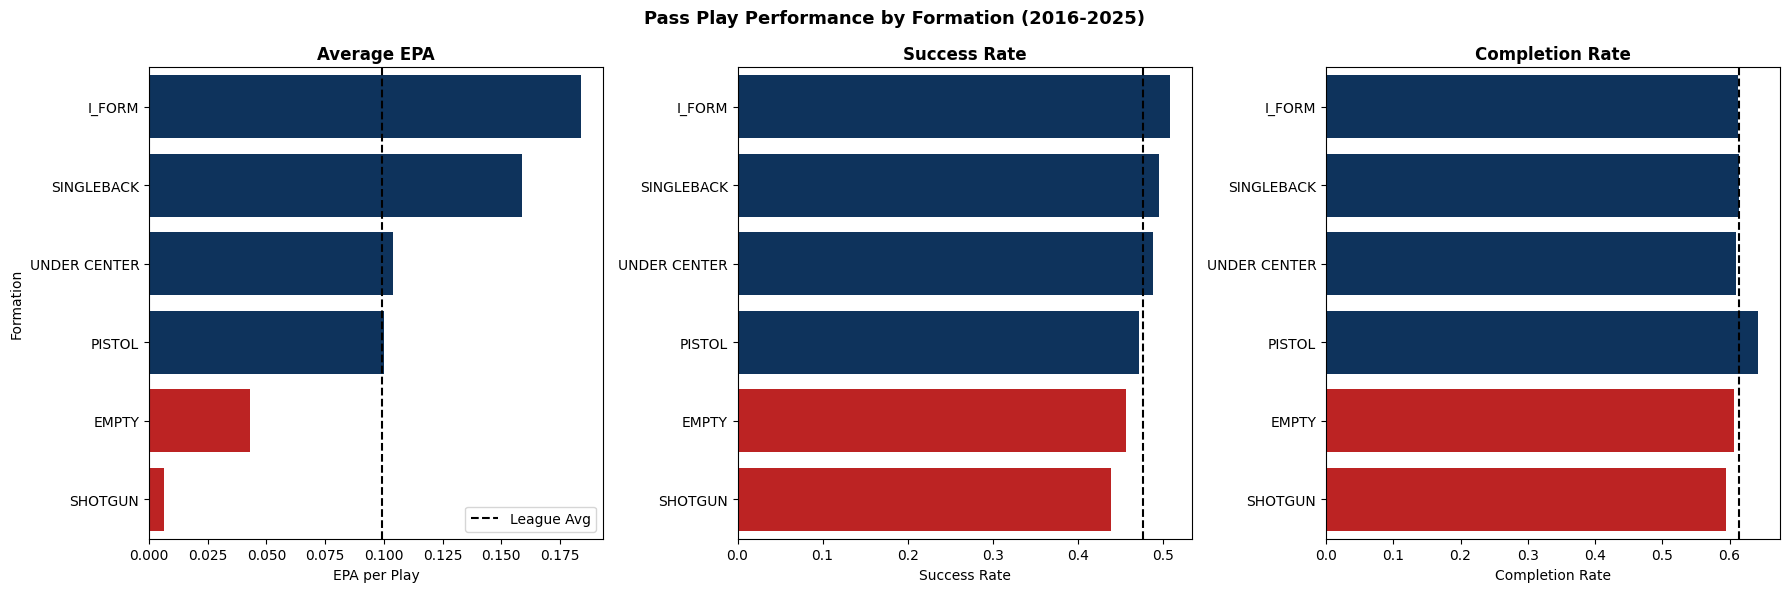

In [3]:
# Pass EPA by formation
pass_formation_epa = pass_plays.groupby('offense_formation').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean'),
    completion_rate=('complete_pass', 'mean')
).reset_index()

pass_formation_epa = pass_formation_epa[pass_formation_epa['plays'] >= 500].sort_values('avg_epa', ascending=False)

print(pass_formation_epa.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

league_avg = pass_formation_epa['avg_epa'].mean()
colors = ['#013369' if x >= league_avg else '#D50A0A' for x in pass_formation_epa['avg_epa']]

# EPA
sns.barplot(data=pass_formation_epa, x='avg_epa', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(pass_formation_epa['offense_formation'], colors)),
            legend=False, ax=axes[0])
axes[0].axvline(x=league_avg, color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('Average EPA', fontweight='bold')
axes[0].set_xlabel('EPA per Play')
axes[0].set_ylabel('Formation')
axes[0].legend()

# Success rate
sns.barplot(data=pass_formation_epa, x='success_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(pass_formation_epa['offense_formation'], colors)),
            legend=False, ax=axes[1])
axes[1].axvline(x=pass_formation_epa['success_rate'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Success Rate', fontweight='bold')
axes[1].set_xlabel('Success Rate')
axes[1].set_ylabel('')

# Completion rate
sns.barplot(data=pass_formation_epa, x='completion_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(pass_formation_epa['offense_formation'], colors)),
            legend=False, ax=axes[2])
axes[2].axvline(x=pass_formation_epa['completion_rate'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[2].set_title('Completion Rate', fontweight='bold')
axes[2].set_xlabel('Completion Rate')
axes[2].set_ylabel('')

plt.suptitle('Pass Play Performance by Formation (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "pass_formation_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Pass Formation EPA](../outputs/figures/pass_formation_epa.png)

The pass formation data delivers one of the most counterintuitive findings in this entire project:

**EPA by formation on pass plays:**
| Formation | Plays | Avg EPA | Success Rate | Completion Rate |
|---|---|---|---|---|
| I-Form | 5,844 | +0.184 | 51% | 61% |
| Singleback | 19,913 | +0.159 | 50% | 61% |
| Under Center | 8,984 | +0.104 | 49% | 61% |
| Pistol | 4,014 | +0.100 | 47% | 64% |
| Empty | 18,708 | +0.043 | 46% | 61% |
| Shotgun | 142,084 | +0.006 | 44% | 59% |

**The finding that changes everything: I-Form generates +0.184 EPA on pass plays — nearly 30x more than Shotgun.**

This is the mirror image of what conventional wisdom would predict. Teams use Shotgun on 70% of pass plays yet it generates the least EPA. Traditional formations like I-Form and Singleback — used on a combined 13% of pass plays — generate dramatically more value per pass attempt.

The explanation is play action. I-Form and Singleback establish the run threat that makes play action passing devastating. When defenses commit to stopping the run, play action passes from these formations catch them completely off guard. Shotgun, by contrast, is an obvious passing formation that puts defenses in their best coverage positions immediately.

**Pistol's high completion rate (64%)** — the highest of any formation — suggests it creates the best throwing windows, likely because it combines the pre-snap read advantages of Shotgun with the run threat of Under Center.

---

### Pass EPA by Coverage Type
Which coverages are most and least vulnerable to the pass?

defense_coverage_type  plays  avg_epa  success_rate  completion_rate
              COVER_3  42582 0.134904      0.499695         0.674769
              COVER_6   9826 0.111071      0.476898         0.657948
              COVER_4  18387 0.098319      0.464350         0.652907
              COVER_1  43146 0.095242      0.447991         0.559055
              COVER_2  24404 0.082000      0.484961         0.694599
              COVER_0   6572 0.055785      0.437462         0.523585
                2_MAN   5580 0.029336      0.423297         0.554122


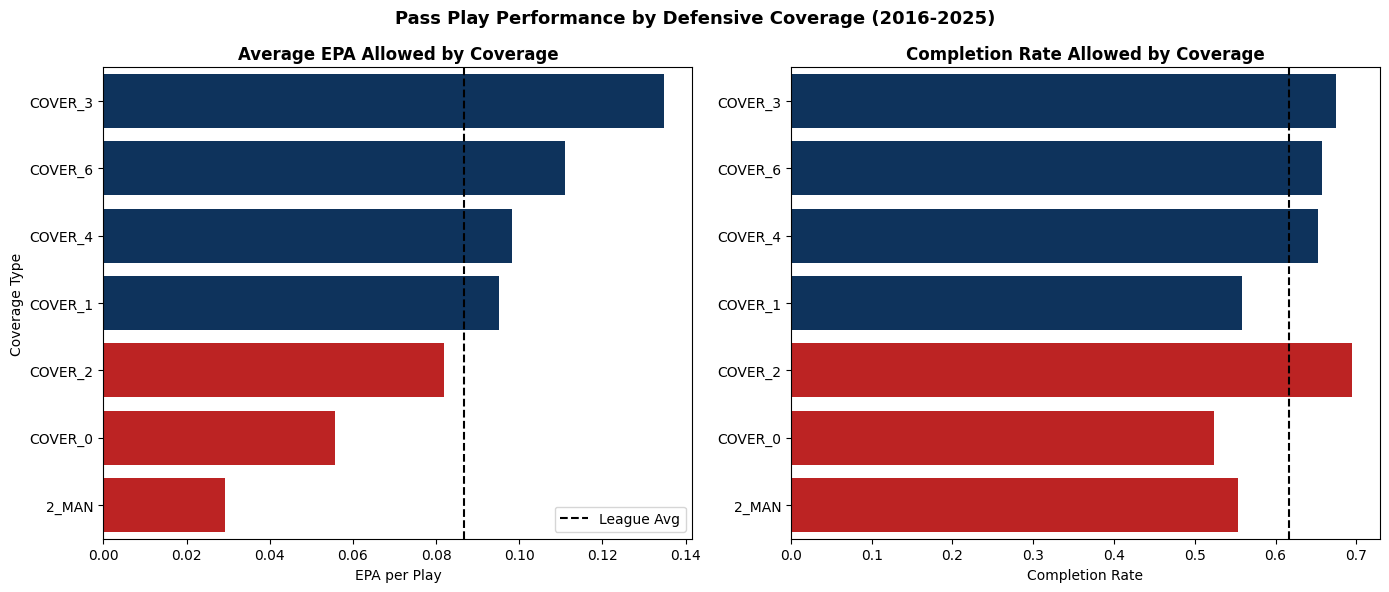

In [5]:
# Pass EPA by coverage type
main_coverages = ['COVER_0', 'COVER_1', 'COVER_2', 'COVER_3', 
                  'COVER_4', 'COVER_6', '2_MAN']

coverage_pass_epa = pass_plays[
    pass_plays['defense_coverage_type'].isin(main_coverages)
].groupby('defense_coverage_type').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean'),
    completion_rate=('complete_pass', 'mean')
).reset_index().sort_values('avg_epa', ascending=False)

print(coverage_pass_epa.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

league_avg = coverage_pass_epa['avg_epa'].mean()
colors = ['#013369' if x >= league_avg else '#D50A0A' for x in coverage_pass_epa['avg_epa']]

sns.barplot(data=coverage_pass_epa, x='avg_epa', y='defense_coverage_type',
            hue='defense_coverage_type',
            palette=dict(zip(coverage_pass_epa['defense_coverage_type'], colors)),
            legend=False, ax=axes[0])
axes[0].axvline(x=league_avg, color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('Average EPA Allowed by Coverage', fontweight='bold')
axes[0].set_xlabel('EPA per Play')
axes[0].set_ylabel('Coverage Type')
axes[0].legend()

sns.barplot(data=coverage_pass_epa, x='completion_rate', y='defense_coverage_type',
            hue='defense_coverage_type',
            palette=dict(zip(coverage_pass_epa['defense_coverage_type'], colors)),
            legend=False, ax=axes[1])
axes[1].axvline(x=coverage_pass_epa['completion_rate'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Completion Rate Allowed by Coverage', fontweight='bold')
axes[1].set_xlabel('Completion Rate')
axes[1].set_ylabel('')

plt.suptitle('Pass Play Performance by Defensive Coverage (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "pass_coverage_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Pass Coverage EPA](../outputs/figures/pass_coverage_epa.png)

Every coverage type allows positive EPA on pass plays — the offense always has an advantage in the passing game. But the gap between coverages is significant:

**EPA allowed by coverage:**
| Coverage | Plays | Avg EPA | Success Rate | Completion Rate |
|---|---|---|---|---|
| Cover 3 | 42,582 | +0.135 | 50% | 67% |
| Cover 6 | 9,826 | +0.111 | 48% | 66% |
| Cover 4 | 18,387 | +0.098 | 46% | 65% |
| Cover 1 | 43,146 | +0.095 | 45% | 56% |
| Cover 2 | 24,404 | +0.082 | 48% | 69% |
| Cover 0 | 6,572 | +0.056 | 44% | 52% |
| 2 Man | 5,580 | +0.029 | 42% | 55% |

**Key findings:**
- **Cover 3 allows the most EPA (+0.135)** — despite being the most commonly called zone coverage, it is the most exploitable by the passing game
- **2 Man is the best pass defense coverage (+0.029)** — tight man coverage with two safeties allows the least EPA and lowest completion rate among zone looks
- **Cover 0 is second best (+0.056)** — all-out blitz suppresses EPA but at the risk of giving up big plays when it fails
- **Cover 2 allows a 69% completion rate** — the highest of any coverage, suggesting short underneath routes thrive against it
- **Cover 1 allows only 56% completion** — man coverage with a single high safety is the best at preventing completions despite allowing moderate EPA

**The tactical implication:** Cover 3 is overused relative to its effectiveness. Defenses calling Cover 3 are giving offenses the best passing environment in the dataset. 2 Man and Cover 0 are the most effective pass defenses but carry significant risk.

---

### Pressure vs No Pressure EPA
How much does defensive pressure change pass play outcomes?

      label  plays   avg_epa  success_rate  completion_rate  sack_rate
No Pressure 137071  0.221128      0.519709         0.697903   0.000015
   Pressure  54430 -0.185197      0.347860         0.454896   0.077182


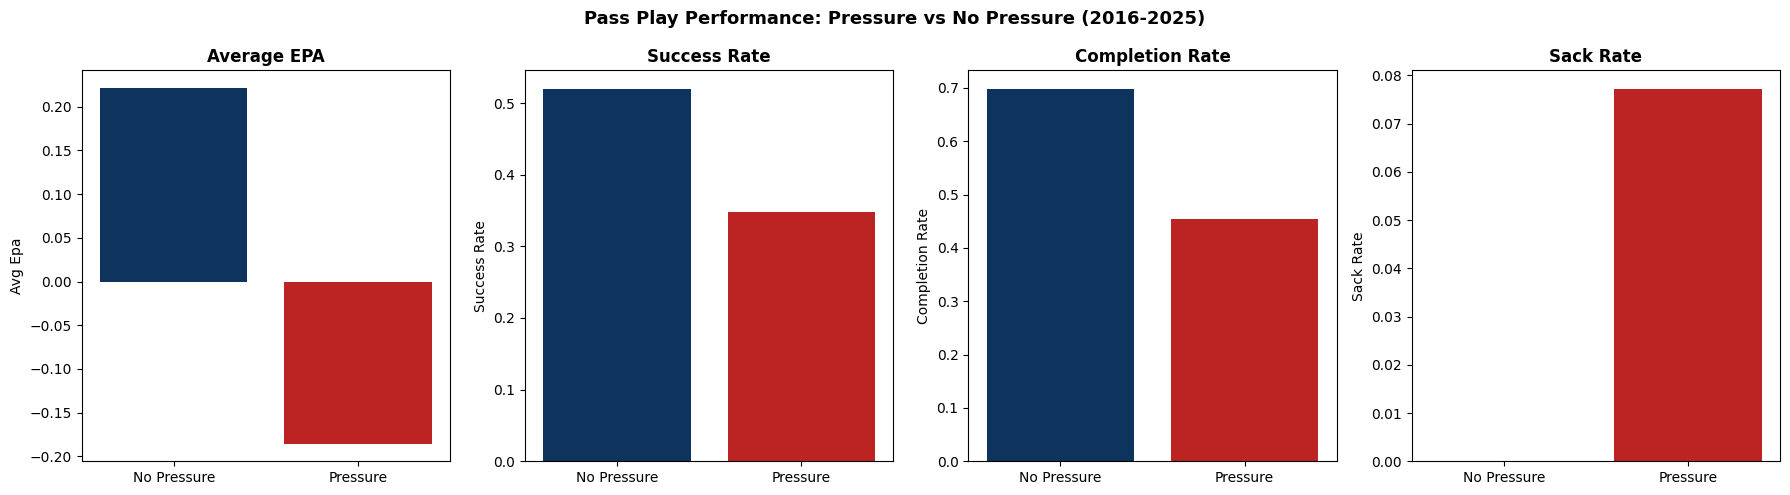

In [6]:
# Pressure vs no pressure
pressure_epa = pass_plays.dropna(subset=['was_pressure']).groupby('was_pressure').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean'),
    completion_rate=('complete_pass', 'mean'),
    sack_rate=('sack', 'mean')
).reset_index()

pressure_epa['label'] = pressure_epa['was_pressure'].map({1.0: 'Pressure', 0.0: 'No Pressure'})
print(pressure_epa[['label', 'plays', 'avg_epa', 'success_rate', 'completion_rate', 'sack_rate']].to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = [('avg_epa', 'Average EPA'), ('success_rate', 'Success Rate'),
           ('completion_rate', 'Completion Rate'), ('sack_rate', 'Sack Rate')]

colors = ['#013369', '#D50A0A']

for ax, (metric, title) in zip(axes, metrics):
    sns.barplot(data=pressure_epa, x='label', y=metric,
                hue='label',
                palette={'No Pressure': '#013369', 'Pressure': '#D50A0A'},
                legend=False, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' ').title())

plt.suptitle('Pass Play Performance: Pressure vs No Pressure (2016-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "pressure_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Pressure vs No Pressure](../outputs/figures/pressure_epa.png)

The pressure data quantifies one of the most fundamental truths in football — getting to the quarterback changes everything:

| Metric | No Pressure | Pressure | Difference |
|---|---|---|---|
| Avg EPA | +0.221 | -0.185 | 0.406 |
| Success Rate | 52% | 35% | 17pp |
| Completion Rate | 70% | 45% | 25pp |
| Sack Rate | 0% | 8% | 8pp |

**The EPA gap of 0.406 per play is enormous.** Pressure turns a strong offensive advantage (+0.221) into a significant defensive advantage (-0.185). This is the single largest performance gap in the entire dataset.

When QBs are kept clean they complete 70% of passes at a 52% success rate. Under pressure those numbers collapse to 45% completion and 35% success. Combined with an 8% sack rate on pressured dropbacks, getting to the quarterback is worth more than any coverage scheme or formation matchup in this project.

**The implication for formation analysis:** formations that provide better pass protection — like 12 and 13 personnel with extra blockers — generate indirect value beyond their raw EPA numbers by reducing pressure rates. This helps explain why heavy personnel packages outperform spread packages in high-stakes situations like 4th down.

---

### Summary
This notebook reveals that the passing game is fundamentally shaped by formation selection and pressure:

1. **I-Form generates +0.184 EPA on pass plays** — nearly 30x more than Shotgun, driven by play action effectiveness
2. **Shotgun is the most used passing formation but generates the least EPA** — a systemic inefficiency in the modern NFL
3. **Cover 3 is the most exploitable coverage** — the most common zone call is also the most generous to offenses
4. **2 Man and Cover 0 are the best pass defenses** — tight coverage and pressure suppress EPA most effectively
5. **Pressure creates a 0.406 EPA swing per play** — generating pass rush is more valuable than any coverage scheme
6. **Pistol has the highest completion rate (64%)** — suggesting it creates the best throwing windows of any formation